# HR knstruc (new): selected-epoch component 1 − corr² on test set

Reads each run's periodic `metrics_snapshot_e*.json` files under
`HR_dyn/results_knstruc_new/`.

Two loading modes are supported:
1. `SELECT_EPOCH = 2500` (or any integer): load exactly `metrics_snapshot_e{SELECT_EPOCH}.json`.
2. `SELECT_EPOCH = None` (default): compare all snapshots from epoch 1100 to 2500 and pick the best result for each metric family.

HR snapshots already store errors, not corr²:
- **max metric / per-component curves:** compute `max(self_x_err, self_y_err, self_z_err, msg_err)` for every snapshot and select the minimum.
- **mean metric:** read `best_component_mean_err` from every snapshot and select the minimum value.


In [11]:
import os, re, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex

In [12]:
# ===== Settings =====
BASE_DIR = 'results_knstruc_new'
SCAN_NODE_SIZES = {20, 40, 60, 80}   # set to None for all
SELECT_EPOCH = None                  # int -> use metrics_snapshot_e{epoch}.json; None -> auto-pick best over epochs
AUTO_EPOCH_MIN = 1100
AUTO_EPOCH_MAX = 2500

PATTERN = re.compile(r'^Nodes(?P<nodes>\d+)_d(?P<degree>[^_]+)_gc(?P<gc>[^_]+)_Ntrain(?P<ntrain>\d+)_hidden(?P<hidden>\d+)_seed(?P<seed>\d+)$')
print(f'BASE_DIR={BASE_DIR}')
print(f'SELECT_EPOCH={SELECT_EPOCH}')
print(f'AUTO_EPOCH_RANGE=[{AUTO_EPOCH_MIN}, {AUTO_EPOCH_MAX}]')


BASE_DIR=results_knstruc_new
SELECT_EPOCH=None
AUTO_EPOCH_RANGE=[1100, 2500]


In [13]:
# ===== Snapshot helpers =====
def list_snapshots(run_dir, epoch_min=AUTO_EPOCH_MIN, epoch_max=AUTO_EPOCH_MAX):
    """Return a sorted list of (epoch, path) for usable metrics snapshots."""
    out = []
    for path in glob.glob(os.path.join(run_dir, 'metrics_snapshot_e*.json')):
        m = re.search(r'e(\d+)', os.path.basename(path))
        if not m:
            continue
        ep = int(m.group(1))
        if epoch_min is not None and ep < epoch_min:
            continue
        if epoch_max is not None and ep > epoch_max:
            continue
        out.append((ep, path))
    return sorted(out)


def load_snapshot(path):
    with open(path) as f:
        return json.load(f)


def snapshot_component_payload(snap, epoch):
    sx = snap.get('self_x_err')
    sy = snap.get('self_y_err')
    sz = snap.get('self_z_err')
    mg = snap.get('msg_err')
    if any(v is None for v in (sx, sy, sz, mg)):
        return None
    comps = [float(sx), float(sy), float(sz), float(mg)]
    return {
        'epoch': int(epoch),
        'err_fx': comps[0],
        'err_fy': comps[1],
        'err_fz': comps[2],
        'err_G': comps[3],
        'max_err': float(np.nanmax(comps)),
        'mean_err_from_components': float(np.nanmean(comps)),
        'component_mean_err': snap.get('component_mean_err'),
        'best_component_mean_err': snap.get('best_component_mean_err'),
        'overall_r2': snap.get('overall_r2'),
        'node_r2_mean': snap.get('node_r2_mean'),
    }


def select_run_metrics(run_dir, select_epoch=SELECT_EPOCH):
    snaps = list_snapshots(run_dir)
    if not snaps:
        return None, 'no_snapshot'

    payloads = []
    for ep, path in snaps:
        if select_epoch is not None and ep != int(select_epoch):
            continue
        payload = snapshot_component_payload(load_snapshot(path), ep)
        if payload is not None:
            payloads.append(payload)

    if not payloads:
        if select_epoch is not None:
            return None, f'missing_epoch_{select_epoch}'
        return None, 'missing_component'

    if select_epoch is not None:
        chosen = payloads[0]
        return {
            'epoch_used_max': chosen['epoch'],
            'epoch_used_mean': chosen['epoch'],
            'selection_mode': f'fixed_e{chosen["epoch"]}',
            'err_fx': chosen['err_fx'],
            'err_fy': chosen['err_fy'],
            'err_fz': chosen['err_fz'],
            'err_G': chosen['err_G'],
            'max_err': chosen['max_err'],
            'mean_err': float(chosen.get('component_mean_err', chosen['mean_err_from_components'])),
            'mean_err_from_components': chosen['mean_err_from_components'],
            'component_mean_err_snap': chosen.get('component_mean_err'),
            'best_component_mean_err_selected': float(chosen.get('best_component_mean_err', chosen.get('component_mean_err', chosen['mean_err_from_components']))),
        }, None

    best_max = min(payloads, key=lambda x: (x['max_err'], x['epoch']))
    mean_candidates = [p for p in payloads if p.get('best_component_mean_err') is not None]
    if mean_candidates:
        best_mean = min(mean_candidates, key=lambda x: (float(x['best_component_mean_err']), x['epoch']))
        mean_err = float(best_mean['best_component_mean_err'])
        epoch_used_mean = int(best_mean['epoch'])
    else:
        best_mean = min(payloads, key=lambda x: (x['mean_err_from_components'], x['epoch']))
        mean_err = float(best_mean['mean_err_from_components'])
        epoch_used_mean = int(best_mean['epoch'])

    return {
        'epoch_used_max': int(best_max['epoch']),
        'epoch_used_mean': epoch_used_mean,
        'selection_mode': f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}',
        'err_fx': best_max['err_fx'],
        'err_fy': best_max['err_fy'],
        'err_fz': best_max['err_fz'],
        'err_G': best_max['err_G'],
        'max_err': best_max['max_err'],
        'mean_err': mean_err,
        'mean_err_from_components': best_max['mean_err_from_components'],
        'component_mean_err_snap': best_max.get('component_mean_err'),
        'best_component_mean_err_selected': mean_err,
    }, None


In [14]:
# (helper functions not needed — reading from JSON directly)

In [15]:
# (model loading not needed — reading from JSON directly)

In [16]:
# ===== Scan runs =====
rows = []
skipped = 0
skipped_reasons = {}
for entry in sorted(os.listdir(BASE_DIR)):
    full = os.path.join(BASE_DIR, entry)
    if not os.path.isdir(full):
        continue
    m = PATTERN.match(entry)
    if not m:
        continue
    num_nodes = int(m.group('nodes'))
    if SCAN_NODE_SIZES is not None and num_nodes not in SCAN_NODE_SIZES:
        continue
    num_train = int(m.group('ntrain'))
    hidden = int(m.group('hidden'))
    seed = int(m.group('seed'))

    selected, reason = select_run_metrics(full, select_epoch=SELECT_EPOCH)
    if selected is None:
        skipped += 1
        skipped_reasons[reason] = skipped_reasons.get(reason, 0) + 1
        continue

    rows.append({
        'run_name': entry,
        'num_nodes': num_nodes,
        'degree_tag': m.group('degree'),
        'gc_tag': m.group('gc'),
        'num_train_samples': num_train,
        'total_samples': num_nodes * num_train,
        'hidden': hidden,
        'seed': seed,
        **selected,
    })

df = pd.DataFrame(rows)
print(f'loaded {len(df)} runs, skipped {skipped} {skipped_reasons}')
if len(df):
    print('num_nodes:', sorted(df.num_nodes.unique()))
    print('seeds:   ', sorted(df.seed.unique()))
    print('epoch_used_max range :', df.epoch_used_max.min(), '-', df.epoch_used_max.max())
    print('epoch_used_mean range:', df.epoch_used_mean.min(), '-', df.epoch_used_mean.max())
    if SELECT_EPOCH is not None:
        diff = (df['mean_err'] - df['component_mean_err_snap']).abs().max()
        print(f'max |mean_err - snap component_mean_err| = {diff:.3e}')
    else:
        print('auto mode: max/per-component and mean may come from different epochs per run')
df.head()


loaded 525 runs, skipped 0 {}
num_nodes: [20, 40, 60, 80]
seeds:    [1, 2, 3, 4, 5]
epoch_used_max range : 1100 - 2500
epoch_used_mean range: 1100 - 2500
auto mode: max/per-component and mean may come from different epochs per run


,run_name,num_nodes,degree_tag,gc_tag,num_train_samples,total_samples,hidden,seed,epoch_used_max,epoch_used_mean,selection_mode,err_fx,err_fy,err_fz,err_G,max_err,mean_err,mean_err_from_components,component_mean_err_snap,best_component_mean_err_selected
0,Nodes20_d3_gc0p535842_Ntrain102_hidden50_seed1,20,3,0p535842,102,2040,50,1,2200,2500,best_e1100_2500,0.037944,0.003966,0.001923,0.097364,0.097364,0.034272,0.035300,0.035300,0.034272
1,Nodes20_d3_gc0p535842_Ntrain102_hidden50_seed2,20,3,0p535842,102,2040,50,2,2400,2500,best_e1100_2500,0.033387,0.004209,0.001241,0.097545,0.097545,0.034078,0.034095,0.034095,0.034078
2,Nodes20_d3_gc0p535842_Ntrain102_hidden50_seed3,20,3,0p535842,102,2040,50,3,2500,2500,best_e1100_2500,0.033475,0.001663,0.000993,0.092312,0.092312,0.032111,0.032111,0.032111,0.032111
3,Nodes20_d3_gc0p535842_Ntrain102_hidden50_seed4,20,3,0p535842,102,2040,50,4,2500,2400,best_e1100_2500,0.037652,0.002871,0.004811,0.099197,0.099197,0.036100,0.036132,0.036132,0.036100
4,Nodes20_d3_gc0p535842_Ntrain102_hidden50_seed5,20,3,0p535842,102,2040,50,5,2500,2500,best_e1100_2500,0.039270,0.003302,0.004170,0.113373,0.113373,0.040013,0.040029,0.040029,0.040013


In [17]:
# ===== Aggregate over seeds =====
ERR_COLS = ['err_fx', 'err_fy', 'err_fz', 'err_G', 'mean_err', 'max_err']
agg_kw = {}
for c in ERR_COLS:
    agg_kw[f'mean_{c}'] = (c, 'mean')
    agg_kw[f'std_{c}']  = (c, 'std')
agg_kw['count'] = ('err_G', 'count')
agg_kw['total_samples'] = ('total_samples', 'first')

agg = (df.groupby(['num_nodes', 'num_train_samples'])
         .agg(**agg_kw).reset_index()
         .sort_values(['num_nodes', 'total_samples']))
node_counts = sorted(df.num_nodes.unique())
print('node sizes:', node_counts)
agg.head()

node sizes: [20, 40, 60, 80]


,num_nodes,num_train_samples,mean_err_fx,std_err_fx,mean_err_fy,std_err_fy,mean_err_fz,std_err_fz,mean_err_G,std_err_G,mean_mean_err,std_mean_err,mean_max_err,std_max_err,count,total_samples
0,20,2,0.864212,0.036393,0.528166,0.073474,0.814695,0.109468,0.904581,0.111324,0.699203,0.015172,0.935211,0.051527,5,40
1,20,7,0.386987,0.069543,0.036324,0.018240,0.383041,0.092042,0.394840,0.093513,0.279906,0.043270,0.445637,0.070941,5,140
2,20,12,0.176762,0.051592,0.025535,0.004276,0.342207,0.032872,0.212011,0.042429,0.163320,0.010996,0.342207,0.032872,5,240
3,20,17,0.058892,0.006780,0.009192,0.001629,0.218963,0.044328,0.061760,0.010917,0.081748,0.013461,0.218963,0.044328,5,340
4,20,22,0.112534,0.076326,0.018297,0.013133,0.250126,0.061221,0.065397,0.035134,0.089143,0.016006,0.250126,0.061221,5,440


In [18]:
# ===== Color map =====
_cmap = LinearSegmentedColormap.from_list('hr_nodes', ['#ca9a96', '#8d7e95', '#56648a', '#6280a5', '#8ca5c0'])
node_color = {n: to_hex(_cmap(i / max(len(node_counts) - 1, 1))) for i, n in enumerate(node_counts)}

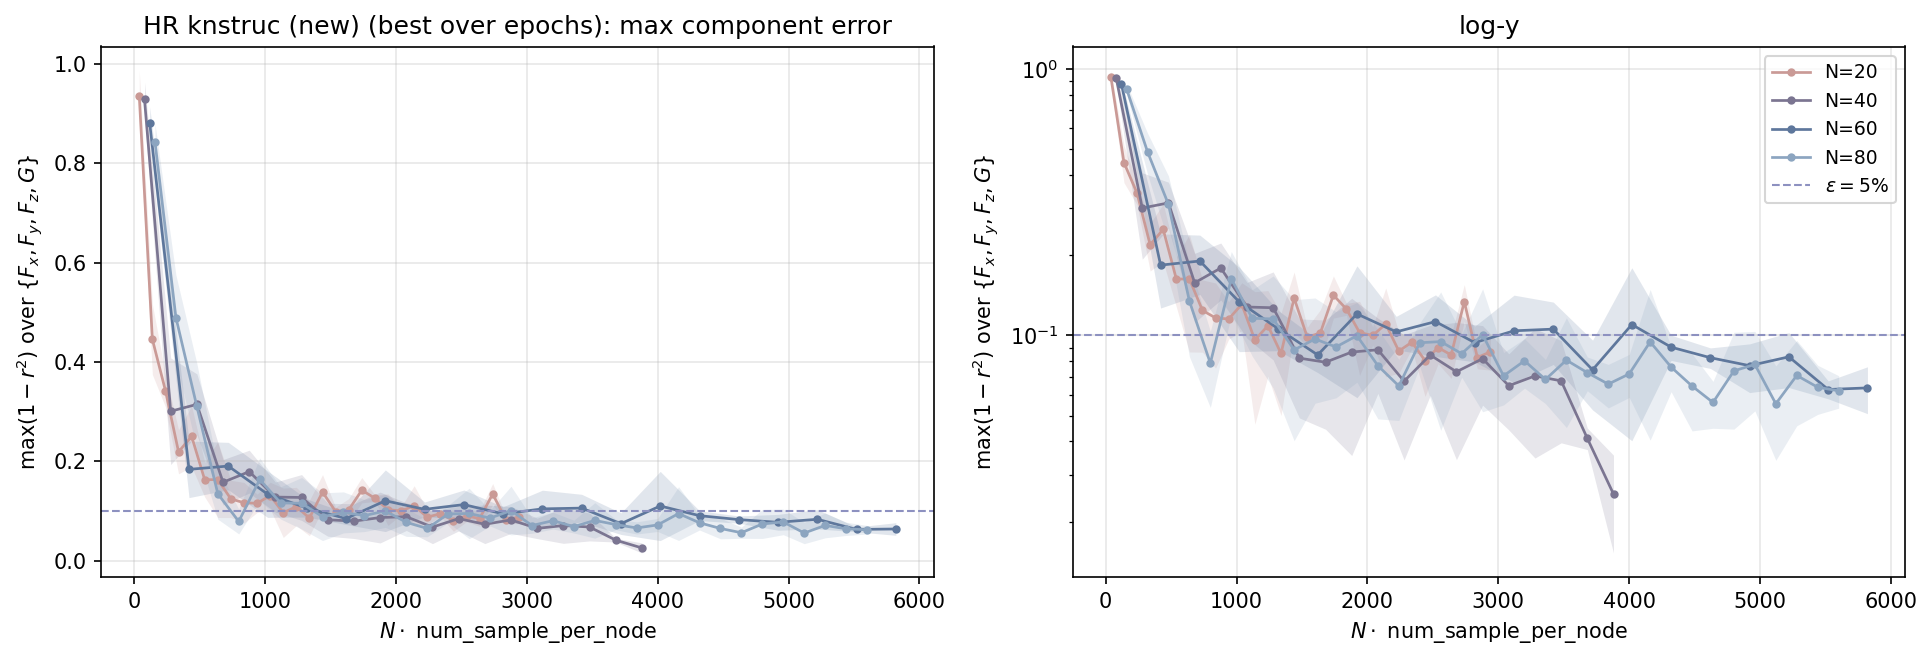

In [19]:
# ===== Plot 1: max component error vs N * num_sample_per_node =====
plot_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else 'best over epochs'
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)
for ax, yscale in [(ax_lin, 'linear'), (ax_log, 'log')]:
    for n in node_counts:
        s = agg[agg.num_nodes == n].sort_values('total_samples')
        if s.empty:
            continue
        x = s['total_samples'].values
        y = s['mean_max_err'].values
        yerr = s['std_max_err'].values
        c = node_color[n]
        ax.plot(x, y, 'o-', color=c, ms=3, lw=1.3, label=f'N={n}')
        ax.fill_between(x, np.clip(y - yerr, 1e-6, None), y + yerr,
                        color=c, alpha=0.18, linewidth=0)
    ax.axhline(0.1, color='#8D91C0', ls='--', lw=1, label='$\epsilon=5\%$')
    ax.set_xlabel('$N \cdot$ num_sample_per_node')
    ax.set_ylabel('max($1-r^2$) over {$F_x,F_y,F_z,G$}')
    ax.set_yscale(yscale)
    ax.grid(alpha=0.3)
ax_lin.set_title(f'HR knstruc (new)' + f' ({plot_tag}): max component error')
ax_log.set_title('log-y')
ax_log.legend(fontsize=9, loc='best')
plt.tight_layout(); plt.show()


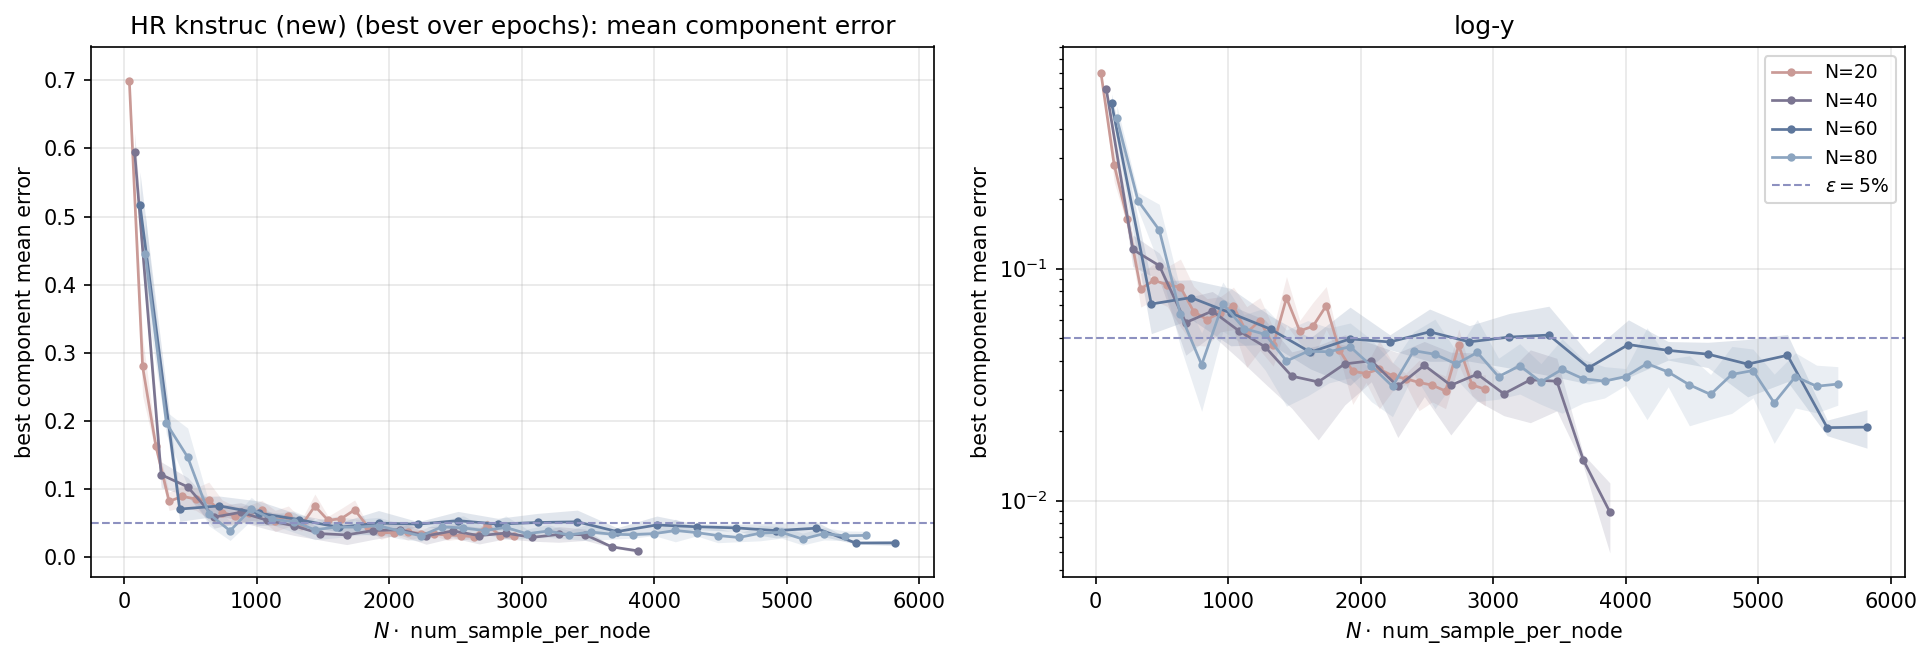

In [20]:
# ===== Plot: MEAN component error vs N * num_sample_per_node =====
plot_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else 'best over epochs'
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)

for ax, yscale in [(ax_lin, 'linear'), (ax_log, 'log')]:
    for n in node_counts:
        s = agg[agg.num_nodes == n].sort_values('total_samples')
        if s.empty:
            continue
        x = s['total_samples'].values
        y = s['mean_mean_err'].values
        yerr = s['std_mean_err'].fillna(0.0).values
        c = node_color[n]
        ax.plot(x, y, 'o-', color=c, ms=3, lw=1.3, label=f'N={n}')
        ax.fill_between(x, np.clip(y - yerr, 1e-6, None), y + yerr,
                        color=c, alpha=0.18, linewidth=0)
    ax.axhline(0.05, color='#8D91C0', ls='--', lw=1, label='$\epsilon=5\%$')
    ax.set_xlabel('$N \cdot$ num_sample_per_node')
    ax.set_ylabel('best component mean error')
    ax.set_yscale(yscale)
    ax.grid(alpha=0.3)
ax_lin.set_title(f'HR knstruc (new)' + f' ({plot_tag}): mean component error')
ax_log.set_title('log-y')
ax_log.legend(fontsize=9, loc='best')
plt.tight_layout(); plt.show()


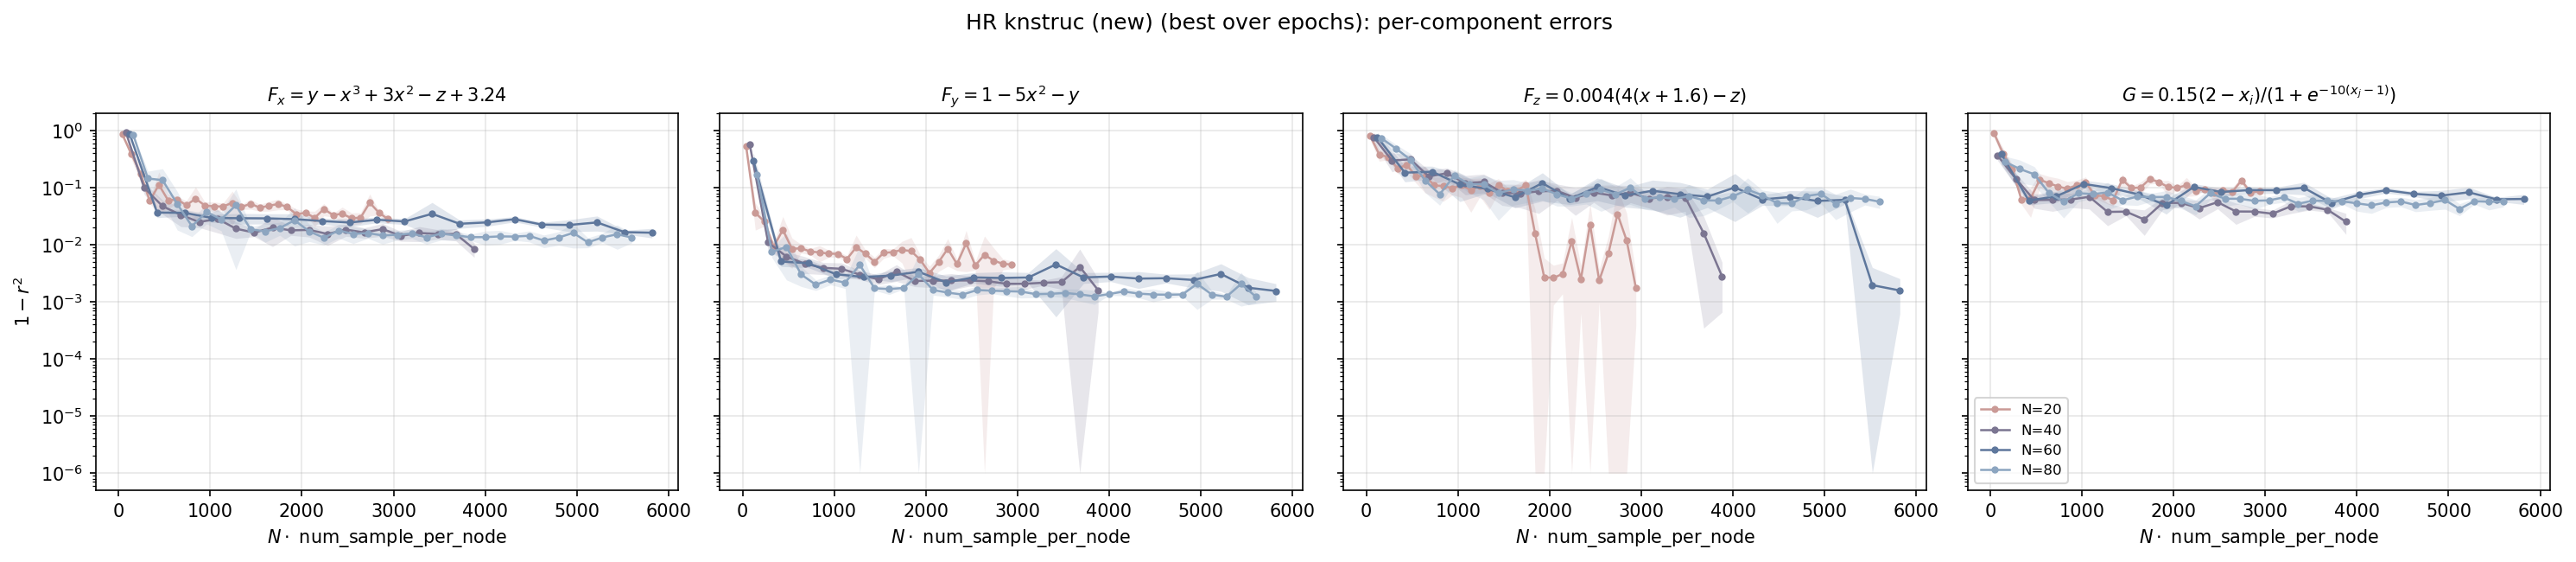

In [21]:
# ===== Plot 2: per-component errors =====
plot_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else 'best over epochs'
panels = [
    ('err_fx', '$F_x = y - x^3 + 3x^2 - z + 3.24$'),
    ('err_fy', '$F_y = 1 - 5x^2 - y$'),
    ('err_fz', '$F_z = 0.004(4(x+1.6) - z)$'),
    ('err_G',  '$G = 0.15(2-x_i)/(1+e^{-10(x_j-1)})$'),
]
fig, axes = plt.subplots(1, 4, figsize=(5*4, 4.2), sharey=True, dpi=150)
for ax, (col, title) in zip(axes, panels):
    for n in node_counts:
        s = agg[agg.num_nodes == n].sort_values('total_samples')
        if s.empty:
            continue
        x = s['total_samples'].values
        y = s[f'mean_{col}'].values
        yerr = s[f'std_{col}'].values
        c = node_color[n]
        ax.plot(x, y, 'o-', color=c, ms=3, lw=1.2, label=f'N={n}')
        ax.fill_between(x, np.clip(y - yerr, 1e-6, None), y + yerr,
                        color=c, alpha=0.18, linewidth=0)
    ax.set_xlabel('$N \cdot$ num_sample_per_node')
    ax.set_yscale('log')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('$1 - r^2$')
axes[-1].legend(fontsize=8)
fig.suptitle(f'HR knstruc (new)' + f' ({plot_tag}): per-component errors', y=1.02)
plt.tight_layout(); plt.show()


In [22]:
# ===== Save cached dataframe =====
tag = 'all' if SCAN_NODE_SIZES is None else '_'.join(str(n) for n in sorted(SCAN_NODE_SIZES))
epoch_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}'
out = f'{BASE_DIR}/component_errors_{epoch_tag}_N{tag}.pkl'
df.to_pickle(out)
print(f'saved -> {out}')


saved -> results_knstruc_new/component_errors_best_e1100_2500_N20_40_60_80.pkl
